# FoundationPose + DINOv2 Integration
Chạy từ đầu hoàn toàn — gộp setup FoundationPose và DINOv2 hypothesis generation.

## Ghi chú

**Multi-dataset support**: Notebook này hỗ trợ chuyển đổi dataset bằng `SCENE_NAME` trong **Cell 42**:
- `'mustard0'` — chai mustard (đối xứng visual nhẹ)
- `'kinect_driller_seq'` — driller (bất đối xứng — DINOv2 retrieval dễ hơn)

**Khi chuyển dataset cần làm gì?**
1. Đổi `SCENE_NAME` ở Cell 42
2. Re-run Cell 44 (icosphere templates với object mới)
3. Re-run Cell 46 (render templates)
4. Re-run Cell 48 (build BoW — sẽ tự lưu cache theo scene name)
5. Re-run các cell ablation

Cache được lưu **riêng cho từng scene** nên không cần xóa khi đổi qua lại — Cell 48 sẽ tự load đúng cache.

**Convention rotation**: Cell 44 dùng `R = R_base.T @ R_inplane.T` (object-in-camera) đã verify với scorer của FoundationPose.

## 1. Kiểm tra GPU

In [1]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [2]:
!nvidia-smi
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")

Sat Jul 25 02:01:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

1. Cache System — Khởi tạo
Chạy cell này TRƯỚC TIÊN mỗi lần mở notebook. Cache lưu trên Google Drive theo GPU type — lần sau sẽ nhanh hơn ~10×.



In [3]:
# ============================================================
# CACHE SYSTEM — Tự động cache mọi bước build nặng lên Drive
# Lần đầu: build bình thường rồi lưu lên Drive (~30-40 phút)
# Lần sau: chỉ cần copy từ Drive về (~2-5 phút)
# ============================================================
import os, subprocess, sys, shutil
import torch

# Detect GPU để cache riêng cho từng GPU architecture
GPU_NAME    = torch.cuda.get_device_name(0).replace(' ', '_')
CUDA_VER    = torch.version.cuda.replace('.', '')
CACHE_KEY   = f'cu{CUDA_VER}_{GPU_NAME}'  # vd: cu121_Tesla_T4
DRIVE_CACHE = f'/gdrive/MyDrive/FoundationPose(1)/colab_cache/{CACHE_KEY}'
os.makedirs(DRIVE_CACHE, exist_ok=True)

print(f'🔑 Cache key: {CACHE_KEY}')
print(f'📂 Cache dir: {DRIVE_CACHE}')

def cache_path(name):
    return f'{DRIVE_CACHE}/{name}.tar.gz'

def cache_exists(name):
    p = cache_path(name)
    if os.path.exists(p):
        size_mb = os.path.getsize(p) / 1e6
        print(f'  ✅ Cache HIT: {name} ({size_mb:.0f} MB)')
        return True
    print(f'  ❌ Cache MISS: {name} → sẽ build và lưu cache')
    return False

def save_cache(src_path, name):
    """Nén src_path thành tar.gz và lưu lên Drive."""
    out = cache_path(name)
    # Tạo thư mục cha tạm để giữ cấu trúc path
    parent = os.path.dirname(src_path)
    base   = os.path.basename(src_path)
    print(f'  💾 Đang lưu cache: {name} ...')
    r = subprocess.run(
        f'tar -czf "{out}" -C "{parent}" "{base}"',
        shell=True, capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'  ⚠️  Lưu cache thất bại: {r.stderr[:200]}')
    else:
        size_mb = os.path.getsize(out) / 1e6
        print(f'  ✅ Cache saved: {name} ({size_mb:.0f} MB) → {out}')

def load_cache(name, restore_parent):
    """Giải nén cache về restore_parent (giống cấu trúc khi save)."""
    inp = cache_path(name)
    os.makedirs(restore_parent, exist_ok=True)
    print(f'  📦 Đang load cache: {name} → {restore_parent} ...')
    r = subprocess.run(
        f'tar -xzf "{inp}" -C "{restore_parent}"',
        shell=True, capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'  ⚠️  Load cache thất bại: {r.stderr[:200]}')
        return False
    print(f'  ✅ Loaded: {name}')
    return True

print('✅ Cache system sẵn sàng!')

🔑 Cache key: cu128_Tesla_T4
📂 Cache dir: /gdrive/MyDrive/FoundationPose(1)/colab_cache/cu128_Tesla_T4
✅ Cache system sẵn sàng!


## 2. Clone FoundationPose (cache-aware)

In [4]:
# ── 2. Clone FoundationPose (có cache) ──
import os

FP_PATH = '/content/FoundationPose'

if cache_exists('foundationpose_repo'):
    load_cache('foundationpose_repo', '/content')
else:
    os.chdir('/content')
    !git clone https://github.com/NVlabs/FoundationPose.git

    # ── Áp dụng các patch NGAY khi clone ──
    # Patch C++14 → C++17
    setup_py = f'{FP_PATH}/bundlesdf/mycuda/setup.py'
    with open(setup_py, 'r') as f: content = f.read()
    with open(setup_py, 'w') as f: f.write(content.replace('-std=c++14', '-std=c++17'))
    print('✅ Patch: C++14 → C++17')

    # Patch .type() → .scalar_type()
    common_cu = f'{FP_PATH}/bundlesdf/mycuda/common.cu'
    with open(common_cu, 'r') as f: content = f.read()
    count = content.count('.type()')
    with open(common_cu, 'w') as f: f.write(content.replace('.type()', '.scalar_type()'))
    print(f'✅ Patch: {count} chỗ .type() → .scalar_type()')

    # Patch build_all.sh — xóa dòng kaolin
    with open(f'{FP_PATH}/build_all.sh', 'r') as f: lines = f.readlines()
    with open(f'{FP_PATH}/build_all.sh', 'w') as f:
        f.writelines([l for l in lines if 'kaolin' not in l.lower()])
    print('✅ Patch: build_all.sh (xóa kaolin)')

    save_cache(FP_PATH, 'foundationpose_repo')

os.chdir(FP_PATH)
print(f'✅ FoundationPose sẵn sàng tại {FP_PATH}')

  ✅ Cache HIT: foundationpose_repo (142 MB)
  📦 Đang load cache: foundationpose_repo → /content ...
  ✅ Loaded: foundationpose_repo
✅ FoundationPose sẵn sàng tại /content/FoundationPose


## 3. System Dependencies

In [5]:
# ── 3. System dependencies ──
# Các thư viện system nhẹ, cài nhanh, không cần cache
import subprocess
r = subprocess.run(
    'apt-get update -qq && apt-get install -y -qq '
    'libeigen3-dev libgl1-mesa-glx libglib2.0-0 '
    'libsm6 libxext6 libxrender-dev libboost-all-dev '
    'cmake ninja-build freeglut3-dev python3-dev xvfb',
    shell=True, capture_output=True, text=True
)
print('✅ System dependencies OK' if r.returncode == 0 else f'⚠️ {r.stderr[-200:]}')

✅ System dependencies OK


## 4. Pytorch3d


In [6]:
# ── 4. PyTorch3D (cache-aware) ──
import sys, glob

PT3D_INSTALL = "/content/pytorch3d_pkg"

def find_pt3d_site(base):
    """Tự tìm site-packages dù python3.10 hay 3.12"""
    patterns = [
        f"{base}/lib/python*/site-packages",
        f"{base}/lib/python*/dist-packages",
    ]
    for p in patterns:
        found = glob.glob(p)
        if found:
            return found[0]
    return None

if cache_exists("pytorch3d"):
    load_cache("pytorch3d", "/content")
else:
    os.makedirs(PT3D_INSTALL, exist_ok=True)
    print("⏳ Đang build PyTorch3D từ source (15-25 phút)...")
    r = subprocess.run(
        f'pip install git+https://github.com/facebookresearch/pytorch3d.git '
        f'--prefix={PT3D_INSTALL} --no-build-isolation',
        shell=True, capture_output=True, text=True
    )
    if r.returncode != 0:
        print("Fallback: install vào site-packages mặc định...")
        os.system('pip install git+https://github.com/facebookresearch/pytorch3d.git')
        r2 = subprocess.run("pip show pytorch3d 2>/dev/null | grep Location",
                             shell=True, capture_output=True, text=True)
        if r2.stdout:
            loc = r2.stdout.strip().split(": ")[1]
            pt3d_dir = os.path.join(loc, "pytorch3d")
            save_cache(pt3d_dir, "pytorch3d")
    else:
        save_cache(PT3D_INSTALL, "pytorch3d")
    print("✅ PyTorch3D build xong!")

# ── Tự động tìm đúng site-packages path ──
pt3d_site = find_pt3d_site(PT3D_INSTALL)
if pt3d_site and pt3d_site not in sys.path:
    sys.path.insert(0, pt3d_site)
    print(f"✅ Thêm vào sys.path: {pt3d_site}")
else:
    # Fallback: tìm pytorch3d trực tiếp trong /content
    pt3d_dirs = glob.glob("/content/**/pytorch3d/__init__.py", recursive=True)
    if pt3d_dirs:
        site = os.path.dirname(os.path.dirname(pt3d_dirs[0]))
        if site not in sys.path:
            sys.path.insert(0, site)
            print(f"✅ Fallback path: {site}")
    else:
        print("⚠️ Không tìm thấy pytorch3d trong /content — thử tìm ở site-packages mặc định")

try:
    import pytorch3d
    print(f"✅ PyTorch3D version: {pytorch3d.__version__}")
except ImportError as e:
    print(f"❌ pytorch3d import lỗi: {e}")
    print("→ Xóa cache và build lại:")
    print(f'  import os; os.remove(cache_path("pytorch3d"))')


  ✅ Cache HIT: pytorch3d (65 MB)
  📦 Đang load cache: pytorch3d → /content ...
  ✅ Loaded: pytorch3d
✅ Fallback path: /content/pytorch3d_pkg/local/lib/python3.12/dist-packages
✅ PyTorch3D version: 0.7.9


In [7]:
# ── Set PYTHONPATH cho tất cả subprocess sau này ──
import os, glob

pt3d_dirs = glob.glob("/content/**/pytorch3d/__init__.py", recursive=True)
if pt3d_dirs:
    pt3d_site = os.path.dirname(os.path.dirname(pt3d_dirs[0]))
    os.environ["PYTHONPATH"] = pt3d_site + ":" + os.environ.get("PYTHONPATH", "")
    print(f"✅ PYTHONPATH set: {pt3d_site}")
else:
    print("⚠️ Không tìm thấy pytorch3d!")

✅ PYTHONPATH set: /content/pytorch3d_pkg/local/lib/python3.12/dist-packages


## 5. Kaolin (cache-aware)
> ⏳ Lần đầu: ~10-15 phút | Lần sau: ~20 giây

In [8]:
# ── 5. Kaolin (cache-aware) ──
import sys, os, glob, importlib.util

KAOLIN_SRC = "/content/kaolin_src"
ARCH = f"{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}"

os.environ["TORCH_CUDA_ARCH_LIST"] = ARCH
os.environ["FORCE_CUDA"]           = "1"
os.environ["IGNORE_TORCH_VER"]     = "1"

if cache_exists('kaolin'):
    load_cache('kaolin', '/content')
    print("⏳ Re-install kaolin từ cache...")
    ret = os.system(
        f'cd {KAOLIN_SRC} && '
        f'TORCH_CUDA_ARCH_LIST="{ARCH}" FORCE_CUDA=1 IGNORE_TORCH_VER=1 '
        f'pip install -e . -q'
    )
    print("✅ Re-install xong!" if ret == 0 else f"⚠️ Re-install thất bại (code {ret})")

else:
    # Bước 1: Clone
    print("⏳ Đang clone kaolin...")
    ret = os.system(
        f'git clone --recursive https://github.com/NVIDIAGameWorks/kaolin.git {KAOLIN_SRC}'
    )
    if ret != 0 or not os.path.exists(f'{KAOLIN_SRC}/setup.py'):
        raise RuntimeError(f"❌ Clone thất bại (exit code {ret})")
    print("✅ Clone xong!")

    # Bước 2: Build
    print(f"⏳ Đang build kaolin (arch={ARCH}, ~10-15 phút)...")
    ret = os.system(
        f'cd {KAOLIN_SRC} && '
        f'TORCH_CUDA_ARCH_LIST="{ARCH}" FORCE_CUDA=1 IGNORE_TORCH_VER=1 '
        f'pip install -e .'
    )
    if ret != 0:
        raise RuntimeError("❌ Build kaolin thất bại!")

    # Bước 3: Verify _C.so trước khi cache
    so = f'{KAOLIN_SRC}/kaolin/_C.so'
    if not os.path.exists(so):
        raise RuntimeError(f"❌ Không thấy _C.so tại {so} — không cache!")
    print(f"✅ _C.so xác nhận: {so}")

    # Bước 4: Cache lên Drive
    save_cache(KAOLIN_SRC, 'kaolin')
    print("✅ Kaolin build xong và đã cache lên Drive!")

# ── Import kaolin bằng importlib (workaround cho editable install) ──
def load_kaolin():
    for mod in list(sys.modules.keys()):
        if 'kaolin' in mod:
            del sys.modules[mod]

    spec = importlib.util.spec_from_file_location(
        "kaolin",
        f"{KAOLIN_SRC}/kaolin/__init__.py",
        submodule_search_locations=[f"{KAOLIN_SRC}/kaolin"]
    )
    mod = importlib.util.module_from_spec(spec)
    mod.__package__ = "kaolin"
    mod.__path__    = [f"{KAOLIN_SRC}/kaolin"]
    sys.modules["kaolin"] = mod
    spec.loader.exec_module(mod)
    return mod

os.chdir('/content/FoundationPose')

try:
    kaolin = load_kaolin()
    print(f"✅ Kaolin version: {kaolin.__version__}")
except Exception as e:
    print(f"❌ Import lỗi: {e}")
    print("→ Thử xóa cache và build lại:")
    print(f'  import os; os.remove(cache_path("kaolin"))')

  ✅ Cache HIT: kaolin (298 MB)
  📦 Đang load cache: kaolin → /content ...
  ✅ Loaded: kaolin
⏳ Re-install kaolin từ cache...
✅ Re-install xong!
✅ Kaolin version: 0.18.0


## 6. NVDiffrast (cache-aware)
> ⏳ Lần đầu: ~3-5 phút | Lần sau: ~10 giây

In [9]:
# ── 6. NVDiffrast (cache-aware) ──
import sys

NVDIFF_SRC = '/tmp/nvdiffrast'

major = torch.cuda.get_device_properties(0).major
minor = torch.cuda.get_device_properties(0).minor
arch  = f'{major}.{minor}'
os.environ['TORCH_CUDA_ARCH_LIST'] = arch
os.environ['FORCE_CUDA']           = '1'

if cache_exists('nvdiffrast'):
    load_cache('nvdiffrast', '/tmp')
    print('⏳ Re-install nvdiffrast từ cache (~30 giây)...')
    r = subprocess.run(
        f'cd {NVDIFF_SRC} && TORCH_CUDA_ARCH_LIST="{arch}" pip install --no-build-isolation . -q',
        shell=True, capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'⚠️ Re-install thất bại: {r.stderr[-200:]}')
    else:
        print('✅ Re-install xong!')
else:
    print(f'⏳ Đang build NVDiffrast lần đầu (arch={arch}, ~3-5 phút)...')
    os.system('pip uninstall nvdiffrast -y -q')
    os.system(f'rm -rf {NVDIFF_SRC}')
    os.system(f'git clone https://github.com/NVlabs/nvdiffrast.git {NVDIFF_SRC} --quiet')
    r = subprocess.run(
        f'cd {NVDIFF_SRC} && TORCH_CUDA_ARCH_LIST="{arch}" pip install --no-build-isolation .',
        shell=True, capture_output=True, text=True
    )
    print(r.stdout[-300:] if r.stdout else '')
    if r.returncode != 0:
        print(f'⚠️ Build thất bại: {r.stderr[-200:]}')
    else:
        save_cache(NVDIFF_SRC, 'nvdiffrast')
        print('✅ NVDiffrast build xong!')

# Reload module sạch
for mod in list(sys.modules.keys()):
    if 'nvdiffrast' in mod:
        del sys.modules[mod]

import nvdiffrast.torch as dr
glctx = dr.RasterizeCudaContext()
print('✅ nvdiffrast OK!')

  ✅ Cache HIT: nvdiffrast (70 MB)
  📦 Đang load cache: nvdiffrast → /tmp ...
  ✅ Loaded: nvdiffrast
⏳ Re-install nvdiffrast từ cache (~30 giây)...
✅ Re-install xong!
✅ nvdiffrast OK!


## 7. mycuda (cache-aware)
> ⏳ Lần đầu: ~2-3 phút | Lần sau: ~10 giây

In [10]:
# ── 7. mycuda (cache-aware) ──
import subprocess, os

MYCUDA_PATH = '/content/FoundationPose/bundlesdf/mycuda'

major = torch.cuda.get_device_properties(0).major
minor = torch.cuda.get_device_properties(0).minor

if cache_exists('mycuda'):
    load_cache('mycuda', '/content/FoundationPose/bundlesdf')
    print('⏳ Re-register mycuda (~30 giây)...')
    r = subprocess.run(
        f'cd {MYCUDA_PATH} && '
        f'TORCH_CUDA_ARCH_LIST="{major}.{minor}" python setup.py develop -q',
        shell=True, capture_output=True, text=True
    )
    print("STDOUT:", r.stdout[-300:] if r.stdout else "(trống)")
    print("STDERR:", r.stderr[-300:] if r.stderr else "(trống)")
    if r.returncode != 0:
        print(f'⚠️ Re-register thất bại')
    else:
        print('✅ mycuda xong!')
else:
    print(f'⏳ Đang build mycuda lần đầu (arch=sm_{major}{minor})...')
    r = subprocess.run(
        f'cd {MYCUDA_PATH} && rm -rf build common.egg-info && '
        f'TORCH_CUDA_ARCH_LIST="{major}.{minor}" python setup.py develop 2>&1 | tail -10',
        shell=True, capture_output=True, text=True
    )
    print(r.stdout)
    if r.returncode != 0:
        print(f'⚠️ Build lỗi: {r.stderr[-300:]}')
    else:
        save_cache(MYCUDA_PATH, 'mycuda')
        print('✅ mycuda build xong!')

%cd /content/FoundationPose

  ✅ Cache HIT: mycuda (22 MB)
  📦 Đang load cache: mycuda → /content/FoundationPose/bundlesdf ...
  ✅ Loaded: mycuda
⏳ Re-register mycuda (~30 giây)...
STDOUT: thon-312-x86_64-linux-gnu.so -> 
Creating /usr/local/lib/python3.12/dist-packages/common.egg-link (link to .)
Adding common 0.0.0 to easy-install.pth file

Installed /content/FoundationPose/bundlesdf/mycuda
Processing dependencies for common==0.0.0
Finished processing dependencies for common==0.0.0

STDERR:        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()

✅ mycuda xong!
/content


## 9. Python Dependencies + Virtual Display

In [11]:
# ── 9. Python dependencies (nhẹ, cài nhanh) ──
os.system(
    "pip install -q kornia opencv-python-headless "
    "matplotlib scipy trimesh open3d "
    "transformations pyrender einops timm "
    "roma ruamel.yaml pypng joblib imageio xformers pyvirtualdisplay "
    "pybind11"  # ← cần cho mycpp build
)
print("✅ Python dependencies OK")

# Verify pybind11
import pybind11
print(f"✅ pybind11: {pybind11.__version__}")


✅ Python dependencies OK
✅ pybind11: 3.0.4


In [12]:
# ── 8. mycpp / build_all.sh (cache — ~2-3 phút) ──
import subprocess, os

# Đảm bảo pybind11 đã được cài
try:
    import pybind11
except ModuleNotFoundError:
    os.system("pip install -q pybind11")
    import pybind11

import torch
FP_PATH      = "/content/FoundationPose"
MYCPP_PATH   = f"{FP_PATH}/mycpp"
pybind11_dir = pybind11.get_cmake_dir()

major = torch.cuda.get_device_properties(0).major
minor = torch.cuda.get_device_properties(0).minor

if cache_exists("mycpp"):
    load_cache("mycpp", FP_PATH)
else:
    print("⏳ Đang build mycpp...")
    r = subprocess.run(
        f'cd {FP_PATH} && '
        f'CMAKE_PREFIX_PATH=/usr/include/eigen3:{pybind11_dir} '
        f'TORCH_CUDA_ARCH_LIST={major}.{minor} '
        f'bash build_all.sh',
        shell=True, capture_output=True, text=True
    )
    print(r.stdout[-500:] if r.stdout else "")
    if r.returncode != 0:
        print(f"⚠️ build_all.sh lỗi: {r.stderr[-300:]}")
    else:
        if os.path.exists(MYCPP_PATH):
            save_cache(MYCPP_PATH, "mycpp")
        print("✅ mycpp build xong!")


  ✅ Cache HIT: mycpp (4 MB)
  📦 Đang load cache: mycpp → /content/FoundationPose ...
  ✅ Loaded: mycpp


## ✅ Tóm tắt Cache

In [13]:
# ── Tóm tắt trạng thái cache ──
import os
items = ['foundationpose_repo', 'pytorch3d', 'kaolin', 'nvdiffrast', 'mycuda', 'mycpp']
print(f'\n{'='*55}')
print(f'  Cache status ({CACHE_KEY})')
print(f'{'='*55}')
total = 0
for item in items:
    p = cache_path(item)
    if os.path.exists(p):
        mb = os.path.getsize(p) / 1e6
        total += mb
        print(f'  ✅ {item:<25} {mb:>7.0f} MB')
    else:
        print(f'  ❌ {item:<25} (chưa cache)')
print(f'{'='*55}')
print(f'  Tổng: {total:.0f} MB trên Google Drive')
print(f'{'='*55}')
print('\n💡 Lần chạy tiếp theo sẽ chỉ mất ~2-5 phút để load từ cache!')


  Cache status (cu128_Tesla_T4)
  ✅ foundationpose_repo           142 MB
  ✅ pytorch3d                      65 MB
  ✅ kaolin                        298 MB
  ✅ nvdiffrast                     70 MB
  ✅ mycuda                         22 MB
  ✅ mycpp                           4 MB
  Tổng: 601 MB trên Google Drive

💡 Lần chạy tiếp theo sẽ chỉ mất ~2-5 phút để load từ cache!


## 14. Mount Google Drive + Copy weights

In [14]:
import os
os.makedirs('/content/FoundationPose/weights', exist_ok=True)

!cp -r "/gdrive/MyDrive/FoundationPose(1)/weights/2023-10-28-18-33-37" /content/FoundationPose/weights/
!cp -r "/gdrive/MyDrive/FoundationPose(1)/weights/2024-01-11-20-02-45" /content/FoundationPose/weights/

!ls /content/FoundationPose/weights/

2023-10-28-18-33-37  2024-01-11-20-02-45


## 15. Tải + giải nén demo data

In [15]:
import os
os.makedirs('/content/FoundationPose(1)/demo_data', exist_ok=True)

!gdown --folder "https://drive.google.com/drive/folders/1pRyFmxYXmAnpku7nGRioZaKrVJtIsroP" \
    --output /content/FoundationPose/demo_data/ \
    --remaining-ok

Retrieving folder contents
Processing file 1LjshMkgy2l_SvBwe4nK2IqP38X2ad0Py kinect_driller_seq.zip
Processing file 1AwV9sESDKMgXGUu2n1o0Pc4x2JGYdVB3 mustard0.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1LjshMkgy2l_SvBwe4nK2IqP38X2ad0Py
From (redirected): https://drive.google.com/uc?id=1LjshMkgy2l_SvBwe4nK2IqP38X2ad0Py&confirm=t&uuid=5af34844-44d4-4a8a-97dd-08341d954ce8
To: /content/FoundationPose/demo_data/demo_data/kinect_driller_seq.zip
100% 943M/943M [00:12<00:00, 75.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1AwV9sESDKMgXGUu2n1o0Pc4x2JGYdVB3
From (redirected): https://drive.google.com/uc?id=1AwV9sESDKMgXGUu2n1o0Pc4x2JGYdVB3&confirm=t&uuid=318cc16e-b010-446b-ae4e-2d19c749441f
To: /content/FoundationPose/demo_data/demo_data/mustard0.zip
100% 362M/362M [00:03<00:00, 93.3MB/s]
Download completed


In [16]:
import os
# Extract cả 2 dataset vào cùng thư mục
!unzip -q -o /content/FoundationPose/demo_data/demo_data/mustard0.zip \
    -d /content/FoundationPose/demo_data/
!unzip -q -o /content/FoundationPose/demo_data/demo_data/kinect_driller_seq.zip \
    -d /content/FoundationPose/demo_data/
print("✅ Demo data ready!")
!ls /content/FoundationPose/demo_data/


✅ Demo data ready!
demo_data  kinect_driller_seq  mustard0


## 16. Lấy object từ ycbv.zip (giải nén từng vật một)


In [17]:
# ============================================================
# Giải nén TỪNG object từ ycbv.zip (Drive) — tiết kiệm đĩa Colab
# ============================================================
import os, glob, shutil

ZIP = '/gdrive/MyDrive/FoundationPose(1)/ycbv.zip'

def fetch_object(ob_id):
    """Giải nén 1 object (1..21) từ zip nếu chưa có. Trả về đường dẫn."""
    name = f'ob_{ob_id:07d}'
    dst  = f'/content/DATA/ref_views_16/{name}'
    if not os.path.exists(f'{dst}/cam_in_ob'):
        os.makedirs('/content/DATA', exist_ok=True)
        print(f'Giải nén {name} ...')
        os.system(f'unzip -q -o "{ZIP}" "ref_views_16/{name}/*" -d /content/DATA')
    subs = sorted(os.path.basename(x) for x in glob.glob(f'{dst}/*'))
    print(f'✅ {name}: {subs}')
    return dst

def drop_object(obj_dir):
    shutil.rmtree(obj_dir, ignore_errors=True)
    print(f'🗑️  đã xóa {obj_dir}')

# Object cho THÍ NGHIỆM QUYẾT ĐỊNH:
#   5 = mustard bottle (gần đối xứng)  |  15 = power drill (bất đối xứng)
OBJ_ID = 15
OBJ = fetch_object(OBJ_ID)


Giải nén ob_0000015 ...
✅ ob_0000015: ['K.txt', 'cam_in_ob', 'depth', 'depth_enhanced', 'gt_model', 'mask', 'model', 'nerf', 'rgb', 'select_frames.yml']


## ===== DINOv2 Integration bắt đầu từ đây =====

### Ý tưởng
- **Gốc**: mỗi frame render + refine **504 poses** → chậm (~1.3s)
- **DINOv2**: tạo 504 templates **offline 1 lần**, mỗi frame chỉ retrieval **top-10** → refine 10 poses (~nhanh hơn ~50x)

### Các bước
1. Load DINOv2
2. Pre-render 504 RGB templates từ icosphere (offline)
3. Extract + lưu DINOv2 features cho 504 templates (offline)
4. Mỗi frame: DINOv2 retrieval top-10 → chỉ refine 10 poses

## 17. Load DINOv2

In [18]:
import torch
import torch.nn.functional as F
from torchvision import transforms

print("Loading DINOv2 ViT-B/14...")
dinov2_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2_model = dinov2_model.cuda().eval()
print(f"✅ DINOv2 loaded! Params: {sum(p.numel() for p in dinov2_model.parameters())/1e6:.1f}M")

# Transform chuẩn cho DINOv2
dino_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Loading DINOv2 ViT-B/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 295MB/s]


✅ DINOv2 loaded! Params: 86.6M


## 18. Config và load mesh (doi test object)






In [19]:
import os, sys, glob
import numpy as np
import trimesh

os.chdir('/content/FoundationPose')
sys.path.insert(0, '/content/FoundationPose')
os.environ["DISPLAY"] = ":0"
os.environ["PYOPENGL_PLATFORM"] = "egl"

# ===== CONFIG (theo OBJ từ cell fetch_object) =====
assert 'OBJ' in dir(), "Chạy cell fetch_object trước!"
SCENE_NAME = f'ob{OBJ_ID:02d}'          # dùng đặt tên file template/BoW theo object

# Mesh GT (gt_model) — chọn đúng file mesh, bỏ qua .mtl/.png đi kèm
_MESH_EXTS = ('.obj', '.ply', '.stl', '.glb', '.gltf')
_all = sorted(glob.glob(f'{OBJ}/gt_model/*'))
_mesh_files = [f for f in _all if f.lower().endswith(_MESH_EXTS)]
assert _mesh_files, (f"Không thấy file mesh {_MESH_EXTS} trong {OBJ}/gt_model — "
                     f"nội dung: {[os.path.basename(x) for x in _all]}")
MESH_PATH = _mesh_files[0]

# Depth scale: 1e-3 (mm->m). Nếu 'median depth' in ra ~5–9 thay vì 0.3–0.9 -> đổi 1e-4
DEPTH_SCALE = 1e-3

Ns         = 42
Ni         = 12
TOP_K      = 20
DEVICE     = 'cuda'
TEMPLATE_PT       = f'/content/FoundationPose/demo_data/dino_templates_{SCENE_NAME}.pt'
TEMPLATE_PATCH_PT = f'/content/FoundationPose/demo_data/dino_patch_templates_{SCENE_NAME}.pt'

mesh = trimesh.load(MESH_PATH, force='mesh')

# Nếu mesh đơn vị mm (bbox ~100+), tự đổi về mét
_diag = float(np.linalg.norm(mesh.bounds[1] - mesh.bounds[0]))
if _diag > 10:
    mesh.apply_scale(1e-3)
    _diag = float(np.linalg.norm(mesh.bounds[1] - mesh.bounds[0]))
    print("⚠️  Mesh có vẻ đơn vị mm → đã scale 1e-3 về mét")

K = np.loadtxt(f'{OBJ}/K.txt').reshape(3, 3)

print(f"✅ Object : {SCENE_NAME}  ({OBJ})")
print(f"✅ gt_model chứa: {[os.path.basename(x) for x in _all]}")
print(f"✅ Mesh   : {MESH_PATH} ({len(mesh.vertices)} verts)")
print(f"   bbox diag = {_diag:.3f} m (kỳ vọng ~0.1–0.4)")
print(f"Config: Ns={Ns}, Ni={Ni}, total={Ns*Ni} templates")


✅ Object : ob15  (/content/DATA/ref_views_16/ob_0000015)
✅ gt_model chứa: ['material.mtl', 'material_0.png', 'model.obj']
✅ Mesh   : /content/DATA/ref_views_16/ob_0000015/gt_model/model.obj (9174 verts)
   bbox diag = 0.269 m (kỳ vọng ~0.1–0.4)
Config: Ns=42, Ni=12, total=504 templates


## 19. Tạo 504 icosphere poses

In [20]:
# ============================================================
# CELL 44 — Tạo Ns × Ni icosphere poses (CONVENTION FIX)
# Sử dụng convention B/C đã verify: R = R_base.T @ R_inplane.T
# Đây là convention object-in-camera của FoundationPose
# ============================================================
import numpy as np
import trimesh

# Sinh icosphere để lấy Ns viewpoints
sphere   = trimesh.creation.icosphere(subdivisions=2)
n_verts  = len(sphere.vertices)
step     = max(1, n_verts // Ns)
cam_positions = sphere.vertices[::step][:Ns]

# Khoảng cách camera-object
diameter = np.linalg.norm(mesh.bounds[1] - mesh.bounds[0])
d        = diameter * 2.5
print(f"Object diameter = {diameter:.3f}m, d = {d:.3f}m")

template_poses = []
for cam_pos in cam_positions:
    # Trục camera nhìn vào origin
    z_axis = -cam_pos / (np.linalg.norm(cam_pos) + 1e-8)
    up = np.array([0, 1, 0])
    if abs(np.dot(z_axis, up)) > 0.99:
        up = np.array([1, 0, 0])
    x_axis = np.cross(up, z_axis)
    x_axis /= (np.linalg.norm(x_axis) + 1e-8)
    y_axis = np.cross(z_axis, x_axis)
    R_base = np.stack([x_axis, y_axis, z_axis], axis=1)

    # Ni in-plane rotations
    for j in range(Ni):
        angle = j * (2 * np.pi / Ni)
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        R_inplane = np.array([
            [cos_a, -sin_a, 0],
            [sin_a,  cos_a, 0],
            [0,      0,     1]
        ])

        # ★ CONVENTION FIX: invert toàn bộ để khớp với object-in-camera ★
        # GỐC SAI : R = R_base @ R_inplane         (camera-in-object)
        # FIX     : R = R_base.T @ R_inplane.T     (object-in-camera)
        R = R_base.T @ R_inplane.T

        pose = np.eye(4)
        pose[:3, :3] = R
        pose[:3,  3] = np.array([0, 0, d])
        template_poses.append(pose)

template_poses = np.array(template_poses)

print(f"✅ Generated {len(template_poses)} template poses (Ns={Ns} × Ni={Ni})")
print(f"   Convention: R = R_base.T @ R_inplane.T (object-in-camera)")
print(f"Pose 0 translation : {template_poses[0][:3, 3]}")
print(f"Pose 100 translation: {template_poses[100][:3, 3]}")


Object diameter = 0.269m, d = 0.673m
✅ Generated 504 template poses (Ns=42 × Ni=12)
   Convention: R = R_base.T @ R_inplane.T (object-in-camera)
Pose 0 translation : [0.         0.         0.67250227]
Pose 100 translation: [0.         0.         0.67250227]


## 20. Render 504 RGB templates (offline — chỉ chạy 1 lần)

Rendering 504 templates (texture thật)...
  100/504
  200/504
  300/504
  400/504
  500/504
✅ Done — RGB: (504, 480, 640, 3)


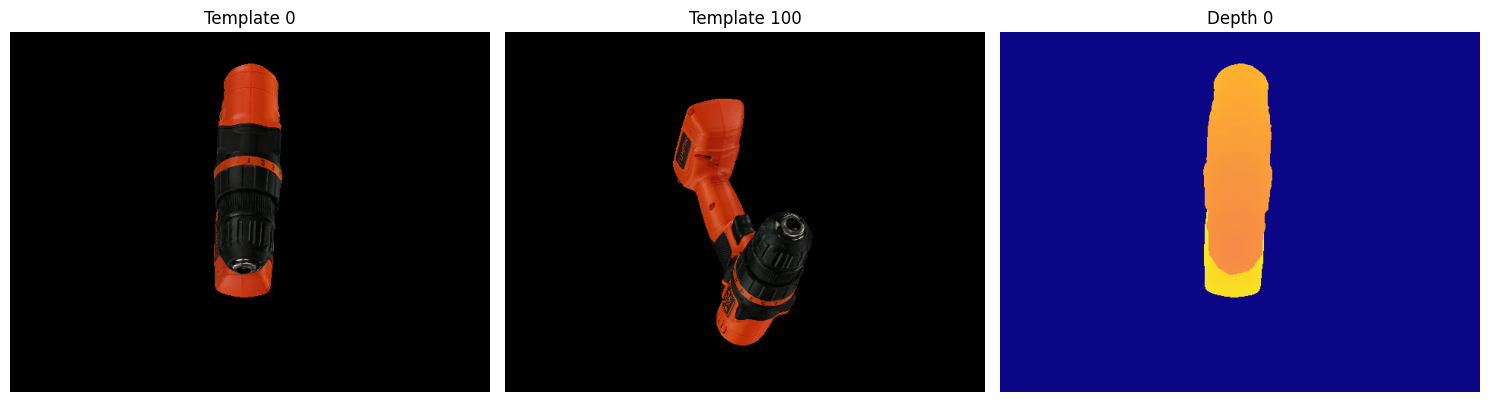

Màu template 0 (sample pixel trung tâm): [18 20 17]


In [21]:
import torch
import torch.nn.functional as F
import nvdiffrast.torch as dr
import numpy as np

glctx_render = dr.RasterizeCudaContext()

def render_rgb_depth_nvdiff(mesh_trimesh, pose, K, H=480, W=640):
    verts = torch.tensor(mesh_trimesh.vertices, dtype=torch.float32).cuda()
    faces = torch.tensor(mesh_trimesh.faces, dtype=torch.int32).cuda().contiguous()

    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    R = torch.tensor(pose[:3,:3], dtype=torch.float32).cuda()
    t = torch.tensor(pose[:3, 3], dtype=torch.float32).cuda()
    verts_cam = (verts @ R.T) + t

    x_ndc = (verts_cam[:,0]*fx/verts_cam[:,2]+cx)/(W/2)-1.0
    y_ndc = (verts_cam[:,1]*fy/verts_cam[:,2]+cy)/(H/2)-1.0
    z_ndc = verts_cam[:,2]/10.0
    w     = torch.ones(len(verts), device='cuda')
    verts_clip = torch.stack([x_ndc,-y_ndc,z_ndc,w], dim=1).unsqueeze(0)

    rast, _ = dr.rasterize(glctx_render, verts_clip, faces, resolution=[H, W])
    obj_mask = (rast[0,:,:,3] > 0)
    mask_f   = obj_mask.unsqueeze(-1).float()

    # ── Texture thật từ TextureVisuals ──
    vis = mesh_trimesh.visual
    tex_img = np.array(vis.material.image.convert('RGB'), dtype=np.float32) / 255.0
    tex_t   = torch.tensor(tex_img, dtype=torch.float32).cuda()
    uvs     = torch.tensor(np.array(vis.uv, dtype=np.float32)).cuda().contiguous()

    uv_attr, _ = dr.interpolate(uvs.unsqueeze(0), rast, faces)
    uv_attr    = uv_attr.squeeze(0).clamp(0, 1)
    H_t, W_t   = tex_t.shape[:2]
    u_px = (uv_attr[...,0]*(W_t-1)).long().clamp(0, W_t-1)
    v_px = ((1-uv_attr[...,1])*(H_t-1)).long().clamp(0, H_t-1)
    color_map = tex_t[v_px, u_px]

    rgb   = (color_map * 255 * mask_f).clamp(0, 255)

    # ── Depth ──
    z_vals     = verts_cam[:,2:3].contiguous()
    depth_a, _ = dr.interpolate(z_vals.unsqueeze(0), rast, faces)
    depth      = depth_a.squeeze(0).squeeze(-1) * obj_mask.float()

    return rgb.cpu().numpy().astype(np.uint8), depth.cpu().numpy()


print(f"Rendering {len(template_poses)} templates (texture thật)...")
template_rgbs   = []
template_depths = []

for i, pose in enumerate(template_poses):
    rgb, depth = render_rgb_depth_nvdiff(mesh, pose, K)
    template_rgbs.append(rgb)
    template_depths.append(depth)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(template_poses)}")

template_rgbs   = np.array(template_rgbs)
template_depths = np.array(template_depths)
print(f"✅ Done — RGB: {template_rgbs.shape}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(template_rgbs[0]);   axes[0].set_title('Template 0');   axes[0].axis('off')
axes[1].imshow(template_rgbs[100]); axes[1].set_title('Template 100'); axes[1].axis('off')
axes[2].imshow(template_depths[0], cmap='plasma'); axes[2].set_title('Depth 0'); axes[2].axis('off')
plt.tight_layout(); plt.show()
print("Màu template 0 (sample pixel trung tâm):", template_rgbs[0][240,320])

## 21. Extract patch descriptors + xây BoW index
Thay CLS token bằng **patch descriptors layer 9** (tương đương layer 18/24 trong FoundPose paper).

In [22]:
from sklearn.cluster import MiniBatchKMeans

PATCH_SIZE   = 14   # ViT-B/14 patch size
INPUT_SIZE   = 224
N_PATCHES_1D = INPUT_SIZE // PATCH_SIZE  # 16
N_PATCHES    = N_PATCHES_1D ** 2          # 256 patches per image
N_BOW_WORDS  = 256  # số visual words cho BoW
N_RETRIEVE   = 8    # số templates retrieve mỗi query (tăng theo TOP_K)
# TEMPLATE_PATCH_PT đã được định nghĩa trong cell 42 với SCENE_NAME


def extract_patch_layer9(model, img_tensor, device='cuda'):
    """Trích xuất patch descriptors từ layer 9 của ViT-B/14 (tương đương layer 18/24 của ViT-L)."""
    with torch.no_grad():
        feats = model.get_intermediate_layers(img_tensor.to(device), n=[9])
        patches = feats[0]  # (B, 256, 768)
        return F.normalize(patches, dim=-1)


def build_template_patch_bank(model, template_rgbs, template_depths, template_poses,
                               K_cam, transform, device='cuda'):
    """
    Xây patch bank cho tất cả templates.
    Mỗi template lưu: descs (P,768), pts3d (P,3) trong object space.
    """
    bank = []
    for t_idx, (rgb, depth, pose) in enumerate(zip(template_rgbs, template_depths, template_poses)):
        # Crop to object
        obj_mask = rgb.sum(axis=2) > 10
        if not obj_mask.any():
            bank.append({'descs': np.zeros((0,768),np.float32), 'pts3d': np.zeros((0,3),np.float32)})
            continue

        rows = np.any(obj_mask, axis=1); cols = np.any(obj_mask, axis=0)
        rmin, rmax = np.where(rows)[0][[0,-1]]
        cmin, cmax = np.where(cols)[0][[0,-1]]
        pr = int((rmax-rmin)*0.1); pc = int((cmax-cmin)*0.1)
        rmin = max(0,rmin-pr); rmax = min(rgb.shape[0]-1,rmax+pr)
        cmin = max(0,cmin-pc); cmax = min(rgb.shape[1]-1,cmax+pc)

        crop_h = rmax-rmin+1; crop_w = cmax-cmin+1
        rgb_crop   = rgb[rmin:rmax+1, cmin:cmax+1]
        depth_crop = depth[rmin:rmax+1, cmin:cmax+1]

        img_t = transform(rgb_crop).unsqueeze(0)
        patch_descs = extract_patch_layer9(model, img_t, device)[0]  # (256,768)

        valid_descs = []; valid_pts3d = []
        for p_idx in range(N_PATCHES):
            row_p = p_idx // N_PATCHES_1D
            col_p = p_idx % N_PATCHES_1D

            # Vị trí center patch trong ảnh 224×224
            cy_224 = 7 + PATCH_SIZE * row_p
            cx_224 = 7 + PATCH_SIZE * col_p

            # Map về crop space
            cy_c = int(cy_224 * crop_h / INPUT_SIZE)
            cx_c = int(cx_224 * crop_w / INPUT_SIZE)
            cy_c = min(cy_c, depth_crop.shape[0]-1)
            cx_c = min(cx_c, depth_crop.shape[1]-1)

            z = depth_crop[cy_c, cx_c]
            if z <= 0.001:
                continue

            # Vị trí trong ảnh gốc
            cy_o = rmin + cy_c
            cx_o = cmin + cx_c

            # Unproject → camera space
            x3d = (cx_o - K_cam[0,2]) * z / K_cam[0,0]
            y3d = (cy_o - K_cam[1,2]) * z / K_cam[1,1]
            pt_cam = np.array([x3d, y3d, z])

            # Chuyển sang object model space
            R_t = pose[:3,:3]; t_t = pose[:3,3]
            pt_obj = R_t.T @ (pt_cam - t_t)

            valid_descs.append(patch_descs[p_idx].cpu().numpy())
            valid_pts3d.append(pt_obj.astype(np.float32))

        if len(valid_descs) > 0:
            bank.append({
                'descs': np.array(valid_descs, dtype=np.float32),
                'pts3d': np.array(valid_pts3d, dtype=np.float32),
            })
        else:
            bank.append({'descs': np.zeros((0,768),np.float32), 'pts3d': np.zeros((0,3),np.float32)})

        if (t_idx+1) % 100 == 0:
            print(f"  Processed {t_idx+1}/{len(template_rgbs)} templates")
    return bank


def build_bow_index(bank, n_words=N_BOW_WORDS):
    """K-means clustering + TF-IDF BoW vectors cho tất cả templates."""
    all_descs = np.concatenate([tb['descs'] for tb in bank if len(tb['descs'])>0], axis=0)
    print(f"Training k-means: {len(all_descs)} descriptors → {n_words} words...")

    km = MiniBatchKMeans(n_clusters=n_words, batch_size=8192, n_init=3, random_state=42, verbose=0)
    km.fit(all_descs)

    N = len(bank)
    df = np.zeros(n_words, dtype=np.float32)
    for tb in bank:
        if len(tb['descs'])==0: continue
        wids = km.predict(tb['descs'])
        df[np.unique(wids)] += 1
    idf = np.log((N+1) / (df+1)).astype(np.float32)

    bow_vecs = np.zeros((N, n_words), dtype=np.float32)
    for i, tb in enumerate(bank):
        if len(tb['descs'])==0: continue
        wids = km.predict(tb['descs'])
        n_t  = len(wids)
        for w in range(n_words):
            bow_vecs[i,w] = (np.sum(wids==w)/n_t) * idf[w]
        norm = np.linalg.norm(bow_vecs[i])
        if norm > 0: bow_vecs[i] /= norm

    return km, bow_vecs, idf


# Chạy offline build
print("=== Bước 1: Build patch bank ===")
template_bank = build_template_patch_bank(
    dinov2_model, template_rgbs, template_depths, template_poses, K, dino_transform
)
avg_patches = np.mean([len(tb['descs']) for tb in template_bank])
print(f"✅ Patch bank built — avg {avg_patches:.0f} valid patches/template")

print("\n=== Bước 2: Build BoW index ===")
bow_kmeans, bow_vectors, bow_idf = build_bow_index(template_bank, n_words=N_BOW_WORDS)
print(f"✅ BoW built — vocab size: {N_BOW_WORDS}, bow_vectors: {bow_vectors.shape}")

# Lưu lại
torch.save({
    'bank':      template_bank,
    'poses':     template_poses,
    'bow_km':    bow_kmeans,
    'bow_vecs':  bow_vectors,
    'bow_idf':   bow_idf,
    'K':         K,
    'Ns': Ns, 'Ni': Ni,
}, TEMPLATE_PATCH_PT)
print(f"✅ Saved → {TEMPLATE_PATCH_PT}")

=== Bước 1: Build patch bank ===
  Processed 100/504 templates
  Processed 200/504 templates
  Processed 300/504 templates
  Processed 400/504 templates
  Processed 500/504 templates
✅ Patch bank built — avg 96 valid patches/template

=== Bước 2: Build BoW index ===
Training k-means: 48521 descriptors → 256 words...
✅ BoW built — vocab size: 256, bow_vectors: (504, 256)
✅ Saved → /content/FoundationPose/demo_data/dino_patch_templates_ob15.pt


In [23]:
# ============================================================
# Retrieval index — thay cho FoundPoseHypothesisGenerator (PnP) cũ.
# Chỉ giữ đúng phần BoW index mà retrieve_top_k_poses cần.
# ============================================================
import torch
class TemplateRetrievalIndex:
    def __init__(self, path):
        d = torch.load(path, map_location='cpu', weights_only=False)
        self.bank     = d['bank']
        self.poses    = d['poses']          # (504,4,4) — pool xoay, ĐỘC LẬP với mesh
        self.bow_km   = d['bow_km']
        self.bow_vecs = d['bow_vecs']
        self.bow_idf  = d['bow_idf']
        self.n_words  = self.bow_vecs.shape[1]
        print(f"[RetrievalIndex] templates={len(self.bank)} vocab={self.n_words}")
fp_gen = TemplateRetrievalIndex(TEMPLATE_PATCH_PT)
_fp = fp_gen


[RetrievalIndex] templates=504 vocab=256


##Side A

In [24]:
# ============================================================
# NEW-A — retrieve_top_k_poses gắn vào fp_gen
# Reuse bow_km, bow_vecs, bow_idf đã có trong fp_gen
# KHÔNG build lại bất cứ thứ gì
# ============================================================
import torch, torch.nn.functional as F
import numpy as np

TOP_K = 20   # số hypothesis đưa vào FP scorer thay vì 252

def _get_bow_tfidf_normed(fp):
    """Cache TF-IDF normalized BoW — tính 1 lần duy nhất."""
    if not hasattr(fp, '_bow_tfidf_normed'):
        bow   = fp.bow_vecs.copy()                           # đã TF-IDF trong Cell 45
        norms = np.linalg.norm(bow, axis=1, keepdims=True) + 1e-8
        fp._bow_tfidf_normed = (bow / norms).astype(np.float32)
        print(f"  [BoW cache] {fp._bow_tfidf_normed.shape}")
    return fp._bow_tfidf_normed

def _query_bow_vec(fp, descs_np):
    """descs_np: (256,768) → TF-IDF BoW (n_words,)"""
    wids = fp.bow_km.predict(descs_np)
    n_t  = len(wids)
    vec  = np.zeros(fp.n_words, np.float32)
    for w in range(fp.n_words):
        vec[w] = (np.sum(wids == w) / n_t) * fp.bow_idf[w]
    norm = np.linalg.norm(vec) + 1e-8
    return vec / norm

def retrieve_top_k_poses(fp, descs_np, k=TOP_K):
    """
    descs_np : (256,768) — từ extract_dino_features()
    Trả về   : torch.Tensor (k,4,4) CUDA — đưa thẳng vào FP scorer
    """
    q_bow  = _query_bow_vec(fp, descs_np)         # (n_words,)
    mat    = _get_bow_tfidf_normed(fp)             # (N, n_words)
    sims   = mat @ q_bow                           # (N,)
    top_k_idx   = np.argsort(sims)[-k:][::-1]
    top_k_poses = fp.poses[top_k_idx]             # (k,4,4) numpy

    return torch.tensor(top_k_poses, device='cuda', dtype=torch.float), sims[top_k_idx]

# Gắn vào fp_gen
_fp = fp_gen
_ = _get_bow_tfidf_normed(_fp)   # warm-up cache
print(f"✅ retrieve_top_k_poses sẵn sàng — TOP_K={TOP_K}")

  [BoW cache] (504, 256)
✅ retrieve_top_k_poses sẵn sàng — TOP_K=20


##Step 1A

In [25]:
# ============================================================
# STEP-1 — Shared feature extractor
# Extract 1 lần → dùng cho cả mask (STEP-2) + retrieval (NEW-B)
# ============================================================

def extract_dino_features(rgb_np, dino_model, transform, device='cuda'):
    """
    Trả về:
        patches_np : (256, 768) numpy  — patch descriptors layer 9
        img_hw     : (H, W)            — kích thước ảnh gốc
    """
    H, W  = rgb_np.shape[:2]
    img_t = transform(rgb_np).unsqueeze(0).to(device)
    with torch.no_grad():
        feats   = dino_model.get_intermediate_layers(img_t, n=[9])
        patches = F.normalize(feats[0][0], dim=-1)   # (256, 768)
    return patches.cpu().numpy(), (H, W)

print("✅ extract_dino_features sẵn sàng")

✅ extract_dino_features sẵn sàng


## ===== PHẦN A: Baseline GỐC frame 0 =====
Chạy `register()` cho frame 0 với GT mask + 252 random hypotheses (default của FoundationPose).

Lưu pose này làm **reference** để so sánh với các pipeline DINOv2.

In [26]:
# ============================================================
# Baseline GỐC: register frame 0 với FULL pool hypotheses
# Guard THEO OBJECT: tự dựng lại estimator khi đổi OBJ (hết bẫy del est_orig)
# ============================================================
import sys, os, time, glob
import numpy as np
import torch
import cv2

os.chdir('/content/FoundationPose')
sys.path.insert(0, '/content/FoundationPose')
os.environ["DISPLAY"] = ":0"
os.environ["PYOPENGL_PLATFORM"] = "egl"

from estimater import FoundationPose, ScorePredictor, PoseRefinePredictor
import Utils   # dùng ĐÚNG module dr mà hàm render của repo dùng (tránh lệch danh tính class)

if ('est_orig' not in globals()) or (globals().get('_est_orig_obj') != OBJ):
    if 'est_orig' in globals():
        # đổi object: tái sử dụng estimator, chỉ nạp mesh mới
        est_orig.reset_object(model_pts=mesh.vertices,
                              model_normals=mesh.vertex_normals, mesh=mesh)
        print(f"♻️  est_orig nạp mesh mới cho {SCENE_NAME}")
    else:
        scorer_orig  = ScorePredictor()
        refiner_orig = PoseRefinePredictor()
        glctx_orig   = Utils.dr.RasterizeCudaContext()
        os.makedirs('/content/FoundationPose/debug_original', exist_ok=True)
        est_orig = FoundationPose(
            model_pts=mesh.vertices, model_normals=mesh.vertex_normals, mesh=mesh,
            scorer=scorer_orig, refiner=refiner_orig,
            debug_dir='/content/FoundationPose/debug_original', debug=0, glctx=glctx_orig)
    _est_orig_obj = OBJ

# đảm bảo context render hợp lệ (tự sửa nếu None hoặc lệch module)
if not isinstance(getattr(est_orig, 'glctx', None), Utils.dr.RasterizeCudaContext):
    est_orig.glctx = Utils.dr.RasterizeCudaContext()
    print('🔧 đã tạo lại glctx cho est_orig')

# ── Load frame 0 trực tiếp từ OBJ ──
rgb_f0   = cv2.cvtColor(cv2.imread(sorted(glob.glob(f'{OBJ}/rgb/*'))[0]), cv2.COLOR_BGR2RGB)
depth_f0 = cv2.imread(sorted(glob.glob(f'{OBJ}/depth/*'))[0], cv2.IMREAD_ANYDEPTH).astype(np.float32) * DEPTH_SCALE
depth_f0[(depth_f0 < 0.001) | (depth_f0 > 2.0)] = 0
mask_f0  = cv2.imread(sorted(glob.glob(f'{OBJ}/mask/*'))[0], cv2.IMREAD_GRAYSCALE) > 0

v = depth_f0[(depth_f0 > 0.001) & mask_f0]
print(f"median depth vùng object (frame0) = {np.median(v):.3f} m  "
      f"{'✅' if 0.2 < np.median(v) < 1.2 else '⚠️ SAI DEPTH_SCALE — đổi trong CONFIG'}")

print(f"=== BASELINE GỐC {SCENE_NAME} — register frame 0 (full pool) ===")
t0 = time.time()
pose_gt = est_orig.register(K=K, rgb=rgb_f0, depth=depth_f0,
                            ob_mask=mask_f0.astype(np.uint8), iteration=5)
t_orig = (time.time() - t0) * 1000
color_f0 = rgb_f0   # alias tương thích với các cell debug cũ
print(f"⏱️  register GỐC: {t_orig:.0f} ms")
print(pose_gt.round(3))



[__init__()] self.cfg: 
 lr: 0.0001
c_in: 6
zfar: 'Infinity'
debug: null
n_view: 1
run_id: 3wy8qqex
use_BN: true
exp_name: 2024-01-11-20-02-45
n_epochs: 62
save_dir: /home/bowenw/debug/2024-01-11-20-02-45/
use_mask: false
loss_type: pairwise_valid
optimizer: adam
batch_size: 64
crop_ratio: 1.1
enable_amp: true
use_normal: false
max_num_key: null
warmup_step: -1
input_resize:
- 160
- 160
max_step_val: 1000
vis_interval: 1000
weight_decay: 0
normalize_xyz: true
resume_run_id: null
clip_grad_norm: 'Infinity'
lr_epoch_decay: 500
render_backend: nvdiffrast
train_num_pair: 5
lr_decay_epochs:
- 50
n_epochs_warmup: 1
make_pair_online: false
gradient_max_norm: 'Infinity'
max_step_per_epoch: 10000
n_rendering_workers: 1
save_epoch_interval: 100
n_dataloader_workers: 100
split_objects_across_gpus: true
ckpt_dir: /content/FoundationPose/learning/training/../../weights/2024-01-11-20-02-45/model_best.pth

[__init__()] self.h5_file:None
[__init__()] Using pretrained model from /content/FoundationPose

median depth vùng object (frame0) = 0.520 m  ✅
=== BASELINE GỐC ob15 — register frame 0 (full pool) ===


[register()] poses:(252, 4, 4)
[register()] after viewpoint, add_errs min:-1.0
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1323: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)
[predict()] ob_in_cams:(252, 4, 4)
[predict()] self.cfg.use_normal:False
[predict()] trans_normalizer:[0.019999999552965164, 0.019999999552965164, 0.05000000074505806], rot_normalizer:0.3490658503988659
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
/content/FoundationPose/learning/training/predict_pose_refine.py:190: FutureWarning: `torch.cuda.amp.auto

⏱️  register GỐC: 7130 ms
[[ 0.942  0.014  0.335 -0.025]
 [-0.201 -0.776  0.598 -0.027]
 [ 0.269 -0.63  -0.728  0.554]
 [ 0.     0.     0.     1.   ]]


### Debug: verify rotation alignment templates vs GT
Cell này quan trọng để chứng minh **convention rotation đã đúng**.
Nếu min rotation diff < 30° → templates align với scorer/refiner → pipeline hoạt động.
Nếu min > 60° → convention vẫn sai, cần debug thêm.

In [27]:
# ============================================================
# DEBUG — Verify icosphere convention với GT pose của GỐC
# ============================================================
import numpy as np

# Pose GỐC frame 0 làm reference
R_gt = pose_gt[:3,:3]

# Tính rotation diff giữa GT và TẤT CẢ template_poses
diffs = []
for pose in template_poses:
    R_t = pose[:3,:3]
    R_rel = R_gt.T @ R_t
    cos = np.clip((np.trace(R_rel)-1)/2, -1, 1)
    diffs.append(np.degrees(np.arccos(cos)))
diffs = np.array(diffs)

print("=" * 65)
print(f"  Verify {len(template_poses)} icosphere templates vs GỐC pose")
print("=" * 65)
print(f"  Min rotation diff      : {diffs.min():>6.1f}°  (idx={diffs.argmin()})")
print(f"  Max rotation diff      : {diffs.max():>6.1f}°")
print(f"  Mean rotation diff     : {diffs.mean():>6.1f}°")
print(f"  Số template < 15°     : {(diffs<15).sum():>3}/{len(diffs)}")
print(f"  Số template < 30°     : {(diffs<30).sum():>3}/{len(diffs)}")
print(f"  Số template < 60°     : {(diffs<60).sum():>3}/{len(diffs)}")

# ── Đánh giá ──
if diffs.min() < 15:
    print("\n  ✅ EXCELLENT — convention OK, có template gần GT (<15°)")
    print("     Pipeline sẽ work tốt.")
elif diffs.min() < 30:
    print("\n  ⚠️  ACCEPTABLE — convention có vẻ OK nhưng grid hơi sparse")
    print("     Pipeline có thể work nhưng accuracy không cao.")
else:
    print(f"\n  ❌ FAIL — min rot_diff = {diffs.min():.1f}° quá lớn!")
    print("     Convention rotation vẫn sai HOẶC object có symmetry.")
    print("     Hãy thử các convention khác trong cell 44.")

# ── Test BoW retrieval cho frame 0 ──
print("\n" + "=" * 65)
print("  Test BoW retrieval với frame 0 (top-20)")
print("=" * 65)
patches_np, _ = extract_dino_features(rgb_f0, dinov2_model, dino_transform)
top_k_torch, sims = retrieve_top_k_poses(_fp, patches_np, k=20)
top_k_np = top_k_torch.cpu().numpy()

retrieved_diffs = []
for rank, (pose, sim) in enumerate(zip(top_k_np, sims)):
    R_t = pose[:3,:3]
    R_rel = R_gt.T @ R_t
    cos = np.clip((np.trace(R_rel)-1)/2, -1, 1)
    rot_d = np.degrees(np.arccos(cos))
    retrieved_diffs.append(rot_d)
    if rank < 10:
        marker = "✓" if rot_d < 30 else (" " if rot_d < 60 else "✗")
        print(f"  #{rank+1:2d} {marker} sim={sim:.3f}  rot_diff_vs_GT={rot_d:6.1f}°")

retrieved_diffs = np.array(retrieved_diffs)
print(f"\n  Top-20 BoW retrieval:")
print(f"    Min rot_diff : {retrieved_diffs.min():.1f}°")
print(f"    Mean rot_diff: {retrieved_diffs.mean():.1f}°")
print(f"    < 30°       : {(retrieved_diffs<30).sum()}/20")

if retrieved_diffs.min() < 30:
    print("\n  ✅ BoW retrieval chứa pose gần GT — refiner sẽ làm phần còn lại")
else:
    print("\n  ❌ BoW retrieval không tìm được pose gần GT!")
    print("     Có thể do object có nhiều symmetry visual hoặc render templates không khớp ảnh thật.")



  Verify 504 icosphere templates vs GỐC pose
  Min rotation diff      :   12.5°  (idx=426)
  Max rotation diff      :  179.5°
  Mean rotation diff     :  123.1°
  Số template < 15°     :   1/504
  Số template < 30°     :   4/504
  Số template < 60°     :  29/504

  ✅ EXCELLENT — convention OK, có template gần GT (<15°)
     Pipeline sẽ work tốt.

  Test BoW retrieval với frame 0 (top-20)
  # 1 ✗ sim=0.349  rot_diff_vs_GT= 166.6°
  # 2 ✗ sim=0.341  rot_diff_vs_GT= 157.7°
  # 3 ✗ sim=0.336  rot_diff_vs_GT= 175.6°
  # 4 ✗ sim=0.332  rot_diff_vs_GT= 175.2°
  # 5 ✗ sim=0.328  rot_diff_vs_GT= 150.3°
  # 6 ✗ sim=0.328  rot_diff_vs_GT= 177.9°
  # 7 ✗ sim=0.320  rot_diff_vs_GT= 172.6°
  # 8 ✗ sim=0.319  rot_diff_vs_GT= 128.6°
  # 9 ✗ sim=0.314  rot_diff_vs_GT=  85.9°
  #10 ✗ sim=0.313  rot_diff_vs_GT= 123.3°

  Top-20 BoW retrieval:
    Min rot_diff : 84.4°
    Mean rot_diff: 148.0°
    < 30°       : 0/20

  ❌ BoW retrieval không tìm được pose gần GT!
     Có thể do object có nhiều symmetry vis

## ===== PRUNING STUDY (mới) — thay cho toàn bộ ablation cũ =====
Ba cell dưới: **(A)** loader GT `cam_in_ob` + tự dò convention + ADD/ADD-S,
**(B)** ba chiến lược sinh hypothesis `random / farthest / dino` (chung pool 504 template),
**(C)** harness eval an toàn-lỗi → CSV.

**Trước khi chạy `dino`:** CONFIG (cell "18. Config") phải trỏ `MESH_PATH` tới
`gt_model/` của object quyết định, và các cell render(20)+BoW(21) đã build cho mesh đó.
`random/farthest` thì không cần render/BoW.


In [28]:
# =============================================================================
# CELL A — GT loader, convention auto-detect, diameter, ADD / ADD-S
# =============================================================================
import os, glob, time, csv
import numpy as np
import cv2
import trimesh
from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist

# --- ĐỌC pose 4x4 từ 1 file cam_in_ob ----------------------------------------
def load_mat4(path):
    M = np.loadtxt(path).reshape(4, 4).astype(np.float64)
    return M

# --- Đường kính mesh (BOP diameter = max khoảng cách 2 điểm bất kỳ) -----------
#     Dùng đỉnh của convex hull cho nhanh (pdist trên toàn bộ verts quá nặng).
def mesh_diameter(mesh):
    hull = mesh.convex_hull
    V = np.asarray(hull.vertices, dtype=np.float64)
    if len(V) > 2000:                      # phòng hờ hull lớn
        V = V[np.random.RandomState(0).choice(len(V), 2000, replace=False)]
    return float(pdist(V).max())           # đơn vị = đơn vị mesh (kỳ vọng: mét)

# --- Lấy tập điểm model để tính ADD (subsample cho nhanh) ---------------------
def sample_model_points(mesh, n=3000):
    V = np.asarray(mesh.vertices, dtype=np.float64)
    if len(V) > n:
        V = V[np.random.RandomState(0).choice(len(V), n, replace=False)]
    return V

# --- ADD (bất đối xứng) & ADD-S (đối xứng, nearest-neighbor) ------------------
def add_err(pose_pred, pose_gt, pts):
    Pp = (pose_pred[:3, :3] @ pts.T + pose_pred[:3, 3:4]).T
    Pg = (pose_gt[:3, :3]   @ pts.T + pose_gt[:3, 3:4]).T
    return float(np.linalg.norm(Pp - Pg, axis=1).mean())

def adds_err(pose_pred, pose_gt, pts):
    Pp = (pose_pred[:3, :3] @ pts.T + pose_pred[:3, 3:4]).T
    Pg = (pose_gt[:3, :3]   @ pts.T + pose_gt[:3, 3:4]).T
    d, _ = cKDTree(Pg).query(Pp, k=1)
    return float(d.mean())

def rot_err_deg(Ra, Rb):
    c = np.clip((np.trace(Ra.T @ Rb) - 1) / 2, -1, 1)
    return float(np.degrees(np.arccos(c)))

# --- AUTO-DETECT convention: cam_in_ob vs nghịch đảo của nó -------------------
#     Chạy register GỐC (full 252) trên 1 frame, so rotation với cả hai khả năng.
#     GT_CONVENTION ∈ {'inv','direct'} sẽ dùng cho toàn bộ eval.
GT_CONVENTION = None

def gt_to_ob_in_cam(cam_in_ob):
    """Trả GT ở dạng ob_in_cam theo convention đã dò."""
    if GT_CONVENTION == 'inv':
        return np.linalg.inv(cam_in_ob)
    elif GT_CONVENTION == 'direct':
        return cam_in_ob.copy()
    raise RuntimeError("Chưa dò convention — chạy detect_convention() trước.")

def detect_convention(est_full, K, rgb, depth, mask, cam_in_ob_frame0):
    """est_full: estimator FoundationPose GỐC (generate_random_pose_hypo mặc định)."""
    global GT_CONVENTION
    pose_fp = est_full.register(K=K, rgb=rgb, depth=depth,
                                ob_mask=mask.astype(np.uint8), iteration=5)
    R_fp = pose_fp[:3, :3]
    cand = {'inv': np.linalg.inv(cam_in_ob_frame0), 'direct': cam_in_ob_frame0}
    errs = {k: rot_err_deg(R_fp, v[:3, :3]) for k, v in cand.items()}
    GT_CONVENTION = min(errs, key=errs.get)
    print(f"[convention] rot_err — inv={errs['inv']:.1f}°, direct={errs['direct']:.1f}°")
    print(f"[convention] CHỌN: '{GT_CONVENTION}'  (khớp {errs[GT_CONVENTION]:.1f}°)")
    if errs[GT_CONVENTION] > 15:
        print("  ⚠️  KHỚP KÉM (>15°). Có thể sai đơn vị depth, mask lệch, "
              "hoặc mesh model/gt_model không cùng hệ. Kiểm tra trước khi chạy tiếp.")
    return pose_fp

# --- Đọc 1 vật thể: ghép cam_in_ob <-> rgb/depth/mask theo thứ tự sort --------
def load_object_frames(obj_dir, depth_scale=1e-3, depth_far=2.0):
    """
    depth_scale: nhân giá trị PNG -> mét. YCB-Video thường 1/10000 (=1e-4) HOẶC
                 mm→m (=1e-3). Xem median-depth in ra: object phải ~0.3–0.9 m.
    Trả list các dict {rgb, depth, mask, cam_in_ob, name}.
    """
    gtf = sorted(glob.glob(f"{obj_dir}/cam_in_ob/*.txt"))
    rgbf = sorted(glob.glob(f"{obj_dir}/rgb/*"))
    dptf = sorted(glob.glob(f"{obj_dir}/depth/*"))
    mskf = sorted(glob.glob(f"{obj_dir}/mask/*"))
    n = min(len(gtf), len(rgbf), len(dptf), len(mskf))
    assert n > 0, f"Không thấy frame trong {obj_dir}"
    if not (len(gtf) == len(rgbf) == len(dptf) == len(mskf)):
        print(f"  ⚠️  Số file lệch nhau (gt={len(gtf)} rgb={len(rgbf)} "
              f"depth={len(dptf)} mask={len(mskf)}) → ghép {n} cái đầu theo sort.")
    frames = []
    med_list = []
    for i in range(n):
        rgb = cv2.cvtColor(cv2.imread(rgbf[i]), cv2.COLOR_BGR2RGB)
        dpt = cv2.imread(dptf[i], cv2.IMREAD_ANYDEPTH).astype(np.float32) * depth_scale
        dpt[(dpt < 0.001) | (dpt > depth_far)] = 0
        msk = cv2.imread(mskf[i], cv2.IMREAD_GRAYSCALE) > 0
        frames.append(dict(rgb=rgb, depth=dpt, mask=msk,
                           cam_in_ob=load_mat4(gtf[i]),
                           name=os.path.basename(gtf[i])))
        v = dpt[(dpt > 0.001) & msk]
        if v.size: med_list.append(np.median(v))
    if med_list:
        md = float(np.median(med_list))
        flag = "✅ hợp lý" if 0.2 < md < 1.2 else "⚠️ NGỜ SAI depth_scale"
        print(f"  median depth trên vùng object = {md:.3f} m  {flag}")
    return frames

print("✅ CELL A ready — load_mat4, mesh_diameter, add_err, adds_err, "
      "detect_convention, load_object_frames")


✅ CELL A ready — load_mat4, mesh_diameter, add_err, adds_err, detect_convention, load_object_frames


In [29]:
# =============================================================================
# CELL B — Chiến lược sinh hypothesis (drop-in cho est.generate_random_pose_hypo)
#   Pool giữ CỐ ĐỊNH = fp_gen.poses (504 template) để so sánh công bằng:
#   khác biệt duy nhất giữa các nhánh là CÁCH CHỌN K pose, không phải pool.
# =============================================================================
import torch, types

def make_pose_pool(fp_gen):
    """(N,4,4) numpy — chính là 504 template pose mà nhánh DINO cũng chọn từ đó."""
    return np.asarray(fp_gen.poses, dtype=np.float32)

# --- Farthest-point sampling trong không gian xoay (geodesic) ----------------
def _rot_geodesic_matrix(R):           # R: (N,3,3) -> (N,N) góc (rad)
    # trace(Ra^T Rb) = sum_ij Ra_ij Rb_ij = <flatten(Ra), flatten(Rb)> = (M @ M.T)
    M = R.reshape(len(R), 9)
    G = M @ M.T
    return np.arccos(np.clip((G - 1) / 2, -1, 1))

def farthest_indices(pool_np, k, seed=0):
    """Chọn k pose phủ đều nhất theo góc xoay (greedy FPS)."""
    R = pool_np[:, :3, :3]
    D = _rot_geodesic_matrix(R)                 # (N,N)
    N = len(R)
    k = min(k, N)
    rng = np.random.RandomState(seed)
    sel = [int(rng.randint(N))]
    mind = D[sel[0]].copy()
    for _ in range(k - 1):
        nxt = int(np.argmax(mind))
        sel.append(nxt)
        mind = np.minimum(mind, D[nxt])
    return np.array(sel)

# --- Cài dispatcher lên 1 estimator ------------------------------------------
def install_strategy(est, fp_gen, seed=0):
    est._pose_pool = torch.as_tensor(make_pose_pool(fp_gen), device='cuda')
    est._pool_np   = make_pose_pool(fp_gen)
    est._rng       = np.random.RandomState(seed)
    est._current_top_k = 20
    est._hypo_strategy = 'random'          # 'dino' | 'random' | 'farthest'
    est._cached_patches = None
    est._far_cache = {}

    def _gen(self, K, rgb, depth, mask, scene_pts=None):
        k = int(self._current_top_k)
        s = self._hypo_strategy
        if s == 'random':
            idx = self._rng.choice(len(self._pool_np),
                                   size=min(k, len(self._pool_np)), replace=False)
            return self._pose_pool[idx]
        if s == 'farthest':
            if k not in self._far_cache:
                self._far_cache[k] = farthest_indices(self._pool_np, k, seed=0)
            return self._pose_pool[self._far_cache[k]]
        if s == 'dino':
            patches = self._cached_patches
            if patches is None:
                patches, _ = extract_dino_features(rgb, dinov2_model, dino_transform)
            topk, _ = retrieve_top_k_poses(_fp, patches, k=k)   # dùng hàm có sẵn
            return topk
        raise ValueError(f"strategy lạ: {s}")

    est.generate_random_pose_hypo = types.MethodType(_gen, est)
    return est

print("✅ CELL B ready — install_strategy(est, fp_gen); "
      "set est._hypo_strategy ∈ {'random','farthest','dino'}, est._current_top_k")


✅ CELL B ready — install_strategy(est, fp_gen); set est._hypo_strategy ∈ {'random','farthest','dino'}, est._current_top_k


In [30]:
# =============================================================================
# CELL C — Harness eval an toàn-lỗi: object × strategy × K  ->  CSV
#   Đo ADD, ADD-S, rot_err(vs GT), t_err, thời gian register END-TO-END.
#   Bọc try/except từng frame -> KHÔNG bao giờ crash cả vòng (fix lỗi KeyError cũ).
# =============================================================================

def build_estimator(mesh):
    """Một estimator DUY NHẤT dùng chung cho mọi object (chống rò rỉ RAM);
    context render tạo qua Utils.dr (tránh lệch danh tính class)."""
    from estimater import FoundationPose, ScorePredictor, PoseRefinePredictor
    import Utils
    global _shared_scorer, _shared_refiner, _shared_glctx, _shared_est
    if '_shared_scorer' not in globals():
        _shared_scorer  = ScorePredictor()
        _shared_refiner = PoseRefinePredictor()
        _shared_glctx   = Utils.dr.RasterizeCudaContext()
    # tự sửa nếu context dùng chung hỏng/lệch module
    if not isinstance(_shared_glctx, Utils.dr.RasterizeCudaContext):
        _shared_glctx = Utils.dr.RasterizeCudaContext()
        if '_shared_est' in globals(): _shared_est.glctx = _shared_glctx
        print('🔧 đã tạo lại _shared_glctx')
    os.makedirs('/content/dbg_eval', exist_ok=True)
    if '_shared_est' in globals():
        # TÁI SỬ DỤNG estimator, chỉ nạp mesh mới
        _shared_est.reset_object(model_pts=mesh.vertices,
                                 model_normals=mesh.vertex_normals, mesh=mesh)
        _shared_est.glctx = _shared_glctx
        return _shared_est
    _shared_est = FoundationPose(model_pts=mesh.vertices, model_normals=mesh.vertex_normals,
                                 mesh=mesh, scorer=_shared_scorer, refiner=_shared_refiner,
                                 debug_dir='/content/dbg_eval', debug=0, glctx=_shared_glctx)
    return _shared_est

def eval_object(obj_dir, mesh_eval, mesh_reg, fp_gen,
                strategies=('random', 'farthest', 'dino'),
                Ks=(1, 3, 5, 10, 20, 50),
                depth_scale=1e-3, detect_conv_here=False, est_full=None):
    """
    mesh_eval: mesh GT (gt_model) -> tính ADD & diameter.
    mesh_reg : mesh đưa vào estimator (gt_model cho model-based, model cho model-free).
    Trả list[dict] kết quả.
    """
    K = np.loadtxt(glob.glob(f"{obj_dir}/K*")[0]).reshape(3, 3)
    frames = load_object_frames(obj_dir, depth_scale=depth_scale)
    diam   = mesh_diameter(mesh_eval)
    pts    = sample_model_points(mesh_eval)
    obj    = os.path.basename(obj_dir.rstrip('/'))
    print(f"\n=== {obj} | {len(frames)} frames | diameter={diam*100:.1f} cm ===")

    # dò convention 1 lần (dùng frame 0)
    if detect_conv_here:
        assert est_full is not None
        detect_convention(est_full, K, frames[0]['rgb'], frames[0]['depth'],
                           frames[0]['mask'], frames[0]['cam_in_ob'])

    est = build_estimator(mesh_reg)
    install_strategy(est, fp_gen)

    rows = []
    for strat in strategies:
        est._hypo_strategy = strat
        for k in Ks:
            est._current_top_k = k
            for fr in frames:
                pose_gt = gt_to_ob_in_cam(fr['cam_in_ob'])
                # cache DINO patches 1 lần / frame (công bằng thời gian)
                est._cached_patches = None
                if strat == 'dino':
                    est._cached_patches, _ = extract_dino_features(
                        fr['rgb'], dinov2_model, dino_transform)
                try:
                    t0 = time.time()
                    pose = est.register(K=K, rgb=fr['rgb'], depth=fr['depth'],
                                        ob_mask=fr['mask'].astype(np.uint8), iteration=5)
                    dt = (time.time() - t0) * 1000
                    row = dict(obj=obj, strategy=strat, top_k=k, frame=fr['name'],
                               time_ms=dt,
                               add_cm=add_err(pose, pose_gt, pts) * 100,
                               adds_cm=adds_err(pose, pose_gt, pts) * 100,
                               rot_err=rot_err_deg(pose[:3, :3], pose_gt[:3, :3]),
                               t_err_cm=np.linalg.norm(pose[:3, 3] - pose_gt[:3, 3]) * 100,
                               diam_cm=diam * 100, ok=True)
                    row['add_pass']  = row['add_cm']  < 10 * diam  # <0.1·d (cm vs cm)
                    row['adds_pass'] = row['adds_cm'] < 10 * diam
                except Exception as e:
                    row = dict(obj=obj, strategy=strat, top_k=k, frame=fr['name'],
                               time_ms=0, add_cm=1e9, adds_cm=1e9, rot_err=180,
                               t_err_cm=1e9, diam_cm=diam * 100, ok=False,
                               add_pass=False, adds_pass=False, err=str(e)[:80])
                rows.append(row)
            # tóm tắt nhanh cho (strat,k)
            sub = [r for r in rows if r['strategy'] == strat and r['top_k'] == k]
            okc = [r for r in sub if r['ok']]
            if okc:
                print(f"  {strat:<9} k={k:>3} | "
                      f"reg={np.mean([r['time_ms'] for r in okc]):5.0f}ms | "
                      f"ADD-S={np.mean([r['adds_cm'] for r in okc]):5.2f}cm | "
                      f"ADD-S<0.1d={100*np.mean([r['adds_pass'] for r in okc]):4.0f}% | "
                      f"rot={np.mean([r['rot_err'] for r in okc]):5.1f}°")
    return rows

def save_csv(rows, path):
    keys = sorted({k for r in rows for k in r})
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader(); w.writerows(rows)
    print(f"✅ CSV → {path}  ({len(rows)} dòng)")

# ------------------------------------------------------------------ HƯỚNG DẪN CHẠY
# 1) Tạo estimator GỐC (nếu chưa có) để dò convention:
#      from estimater import FoundationPose, ScorePredictor, PoseRefinePredictor
#      # ... est_orig như trong notebook của bạn ...
#
# 2) THÍ NGHIỆM QUYẾT ĐỊNH (1–2 object có sẵn DINO bank) — random vs farthest vs dino:
#      gt_mesh  = trimesh.load(f"{OBJ}/gt_model/<ten_mesh>", force='mesh')
#      reg_mesh = gt_mesh                       # model-based
#      rows = eval_object(OBJ, gt_mesh, reg_mesh, fp_gen,
#                         strategies=('random','farthest','dino'),
#                         Ks=(1,3,5,10,20,50),
#                         detect_conv_here=True, est_full=est_orig)
#      save_csv(rows, '/content/decisive.csv')
#   -> Nếu 'dino' KHÔNG hơn 'random'/'farthest' ở cùng K: đổi khung bài (Hướng 1).
#
# 3) BREADTH (nhiều object, chỉ cần random+farthest — KHÔNG cần render/BoW):
#      all_rows = []
#      for OBJ in OBJECT_FOLDERS:
#          gm = trimesh.load(glob.glob(f"{OBJ}/gt_model/*.obj")[0], force='mesh')
#          all_rows += eval_object(OBJ, gm, gm, fp_gen,
#                                  strategies=('random','farthest'),
#                                  Ks=(1,3,5,10,20,50,100))
#      save_csv(all_rows, '/content/breadth.csv')
print("✅ CELL C ready — build_estimator, eval_object, save_csv")





✅ CELL C ready — build_estimator, eval_object, save_csv


In [31]:
# ============================================================
# THÍ NGHIỆM QUYẾT ĐỊNH — random vs farthest vs dino (model-based)
# OBJ + mesh đã set ở fetch_object/CONFIG. Mesh register = mesh eval = gt_model.
# ============================================================
import numpy as np

rows = eval_object(
    OBJ, mesh_eval=mesh, mesh_reg=mesh,
    fp_gen=fp_gen,
    strategies=('random','farthest','dino'),
    Ks=(1,3,5,10,20,50),
    depth_scale=DEPTH_SCALE,
    detect_conv_here=True, est_full=est_orig,
)
save_csv(rows, f'/gdrive/MyDrive/FoundationPose(1)/decisive_{SCENE_NAME}.csv')  # lưu vào Drive

# Đọc nhanh: nếu 'dino' KHÔNG hơn 'random'/'farthest' ở cùng K -> chốt Hướng 1.
print(f"\n{'':<10} {'K':>3} | {'ADD-S':>7} | {'pass<0.1d':>9} | {'time':>7}")
for s in ('random','farthest','dino'):
    for k in (3,5,10,20):
        sub=[r for r in rows if r['strategy']==s and r['top_k']==k and r['ok']]
        if sub:
            print(f"{s:<10} {k:>3} | {np.mean([r['adds_cm'] for r in sub]):5.2f}cm "
                  f"| {100*np.mean([r['adds_pass'] for r in sub]):8.0f}% "
                  f"| {np.mean([r['time_ms'] for r in sub]):5.0f}ms")

# Xong object này? Chạy tiếp object thứ 2 (power drill):
#   drop_object(OBJ); OBJ_ID = 15; OBJ = fetch_object(15)
#   -> chạy lại CONFIG -> icosphere -> render -> BoW -> baseline -> cell này


[register()] Welcome
[register()] poses:(252, 4, 4)
[register()] after viewpoint, add_errs min:-1.0
[predict()] ob_in_cams:(252, 4, 4)
[predict()] self.cfg.use_normal:False
[predict()] trans_normalizer:[0.019999999552965164, 0.019999999552965164, 0.05000000074505806], rot_normalizer:0.3490658503988659
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
/content/FoundationPose/learning/training/predict_pose_refine.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.amp):
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch


  median depth trên vùng object = 0.838 m  ✅ hợp lý

=== ob_0000015 | 16 frames | diameter=22.6 cm ===


[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop

[convention] rot_err — inv=1.6°, direct=75.7°
[convention] CHỌN: 'inv'  (khớp 1.6°)


[__init__()] init done
[__init__()] welcome
[__init__()] self.cfg: 
 lr: 0.0001
c_in: 6
zfar: .inf
debug: null
w_rot: 0.1
n_view: 1
run_id: null
use_BN: true
rot_rep: axis_angle
ckpt_dir: /content/FoundationPose/learning/training/../../weights/2023-10-28-18-33-37/model_best.pth
exp_name: 2023-10-28-18-33-37
save_dir: /tmp/2023-10-28-18-33-37/
loss_type: l2
optimizer: adam
trans_rep: tracknet
batch_size: 64
crop_ratio: 1.2
use_normal: false
BN_momentum: 0.1
max_num_key: null
warmup_step: -1
input_resize:
- 160
- 160
max_step_val: 1000
normal_uint8: false
vis_interval: 1000
weight_decay: 0
n_max_objects: null
normalize_xyz: true
clip_grad_norm: 'Infinity'
rot_normalizer: 0.3490658503988659
trans_normalizer:
- 0.019999999552965164
- 0.019999999552965164
- 0.05000000074505806
max_step_per_epoch: 25000
val_epoch_interval: 10
n_dataloader_workers: 60
enable_amp: true
use_mask: false

[__init__()] self.h5_file:
[__init__()] Using pretrained model from /content/FoundationPose/learning/training

...

  dino      k= 10 | reg=  331ms | ADD-S= 1.73cm | ADD-S<0.1d=  75% | rot= 84.7°


[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] ob_in_cams:(20, 4, 4)
[predict()] self.cfg.use_normal:False
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch(

  dino      k= 20 | reg=  462ms | ADD-S= 1.44cm | ADD-S<0.1d=  81% | rot= 93.8°


[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop_data_batch()] warp done
[make_crop_data_batch()] pose batch data done
[predict()] forward start
[predict()] forward done
[predict()] making cropped data
[make_crop_data_batch()] Welcome make_crop_data_batch
[make_crop_data_batch()] make tf_to_crops done
[make_crop_data_batch()] render done
[make_crop

  dino      k= 50 | reg=  969ms | ADD-S= 0.51cm | ADD-S<0.1d=  94% | rot= 32.2°
✅ CSV → /gdrive/MyDrive/FoundationPose(1)/decisive_ob15.csv  (288 dòng)

             K |   ADD-S | pass<0.1d |    time
random       3 |  1.94cm |       75% |   266ms
random       5 |  2.46cm |       62% |   278ms
random      10 |  0.56cm |       94% |   329ms
random      20 |  0.30cm |      100% |   453ms
farthest     3 |  2.75cm |       56% |   295ms
farthest     5 |  1.63cm |       69% |   285ms
farthest    10 |  1.01cm |       88% |   313ms
farthest    20 |  0.72cm |       94% |   453ms
dino         3 |  1.81cm |       75% |   282ms
dino         5 |  1.99cm |       75% |   261ms
dino        10 |  1.73cm |       75% |   331ms
dino        20 |  1.44cm |       81% |   462ms


## ANCHOR — accuracy của FULL search (K=504) trên 5 object đại diện


In [32]:
# ============================================================
# FULL-GRID ANCHOR — accuracy + time với K=252 (đúng ngân sách
# hypothesis của FoundationPose GỐC; K=504 bị CUDA OOM trên T4).
# 5 object: dễ (1), trung bình (5,13), khó (15,18). Có resume.
# MẸO VRAM: chạy cell này TRƯỚC khi load DINOv2 (anchor không cần DINO).
# ============================================================
import trimesh, glob, os, csv, gc, torch
import numpy as np

def append_csv(rows, path):
    keys = sorted({k for r in rows for k in r})
    new_file = not os.path.exists(path)
    with open(path, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys, extrasaction='ignore')
        if new_file: w.writeheader()
        w.writerows(rows)
    print(f'✅ +{len(rows)} dòng -> {path}')

# dọn VRAM trước khi chạy (est_orig/dino nếu có)
for _v in ('est_orig','scorer_orig','refiner_orig','glctx_orig'):
    if _v in globals(): del globals()[_v]
gc.collect(); torch.cuda.empty_cache()

ANCHOR_CSV = '/gdrive/MyDrive/FoundationPose(1)/anchor_full.csv'
done = set()
if os.path.exists(ANCHOR_CSV):
    done = {r['obj'] for r in csv.DictReader(open(ANCHOR_CSV))}
    print('Đã xong:', sorted(done))

for ob_id in (1, 5, 13, 15, 18):
    name = f'ob_{ob_id:07d}'
    if name in done: print(f'⏭️ {name}'); continue
    O = fetch_object(ob_id)
    gmf = sorted(f for f in glob.glob(f'{O}/gt_model/*') if f.lower().endswith(('.obj','.ply','.stl')))
    gm = trimesh.load(gmf[0], force='mesh')
    if float(np.linalg.norm(gm.bounds[1]-gm.bounds[0])) > 10: gm.apply_scale(1e-3)
    rows = eval_object(O, gm, gm, fp_gen, strategies=('random',), Ks=(252,),
                       depth_scale=DEPTH_SCALE, detect_conv_here=False)
    append_csv(rows, ANCHOR_CSV)
    del rows, gm
    drop_object(O); gc.collect(); torch.cuda.empty_cache()
print('✅ ANCHOR xong ->', ANCHOR_CSV)



Đã xong: ['ob_0000001', 'ob_0000005', 'ob_0000013', 'ob_0000015', 'ob_0000018']
⏭️ ob_0000001
⏭️ ob_0000005
⏭️ ob_0000013
⏭️ ob_0000015
⏭️ ob_0000018
✅ ANCHOR xong -> /gdrive/MyDrive/FoundationPose(1)/anchor_full.csv


## Decisive object thứ 2 — ob15 (power drill, bất đối xứng)
Trình tự (mỗi bước = chạy lại cell tương ứng phía trên):
1. Cell **fetch_object**: sửa `OBJ_ID = 15` → chạy.
2. **CONFIG** → tự trỏ mesh ob15, bank tên `ob15`.
3. **icosphere → render → BoW** (~20 phút; bank ob05 KHÔNG dùng được cho mesh khác).
   Xong: `!cp /content/FoundationPose/demo_data/dino_*ob15*.pt "/gdrive/MyDrive/FoundationPose(1)/"`
4. **TemplateRetrievalIndex** + 2 cell Side A (để `fp_gen` trỏ bank ob15).
5. **Baseline** — guard mới tự nạp mesh ob15, KHÔNG cần `del est_orig`.
6. **CELL A → B → C** (chạy lại cho sạch `GT_CONVENTION`).
7. **Cell decisive** → tự lưu `decisive_ob15.csv` (tên theo SCENE_NAME).


In [33]:
# ============================================================
# BREADTH — 21 object, random+farthest (KHÔNG cần render/BoW/dino)
# Giải nén -> chạy -> xóa từng object. CSV lưu Drive SAU MỖI object (resume được).
# ============================================================
import trimesh, glob, os, csv
import numpy as np

CSV_OUT = '/gdrive/MyDrive/FoundationPose(1)/breadth.csv'

# resume: đọc object đã chạy xong
done = set()
if os.path.exists(CSV_OUT):
    with open(CSV_OUT) as f:
        done = {r['obj'] for r in csv.DictReader(f)}
    print('Đã có kết quả:', sorted(done))

all_rows = []
if os.path.exists(CSV_OUT):
    with open(CSV_OUT) as f:
        all_rows = list(csv.DictReader(f))

for ob_id in range(1, 22):
    name = f'ob_{ob_id:07d}'
    if name in done:
        print(f'⏭️  {name} đã xong, bỏ qua'); continue
    O = fetch_object(ob_id)
    try:
        gm_files = sorted(f for f in glob.glob(f'{O}/gt_model/*')
                          if f.lower().endswith(('.obj','.ply','.stl')))
        gm = trimesh.load(gm_files[0], force='mesh')
        if float(np.linalg.norm(gm.bounds[1]-gm.bounds[0])) > 10:
            gm.apply_scale(1e-3)   # mesh mm -> m
        all_rows += eval_object(O, gm, gm, fp_gen,
                                strategies=('random','farthest'),
                                Ks=(1,3,5,10,20,50),
                                depth_scale=DEPTH_SCALE,
                                detect_conv_here=False)
        save_csv(all_rows, CSV_OUT)          # lưu Drive NGAY sau mỗi object
    except Exception as e:
        print(f'⚠️  {name} lỗi: {e} — bỏ qua, chạy tiếp')
    drop_object(O)
print('✅ BREADTH xong ->', CSV_OUT)


Đã có kết quả: ['ob_0000001', 'ob_0000002', 'ob_0000003', 'ob_0000004', 'ob_0000005', 'ob_0000006', 'ob_0000007', 'ob_0000008', 'ob_0000009', 'ob_0000010', 'ob_0000011', 'ob_0000012', 'ob_0000013', 'ob_0000014', 'ob_0000015', 'ob_0000016', 'ob_0000017', 'ob_0000018', 'ob_0000019', 'ob_0000020', 'ob_0000021']
⏭️  ob_0000001 đã xong, bỏ qua
⏭️  ob_0000002 đã xong, bỏ qua
⏭️  ob_0000003 đã xong, bỏ qua
⏭️  ob_0000004 đã xong, bỏ qua
⏭️  ob_0000005 đã xong, bỏ qua
⏭️  ob_0000006 đã xong, bỏ qua
⏭️  ob_0000007 đã xong, bỏ qua
⏭️  ob_0000008 đã xong, bỏ qua
⏭️  ob_0000009 đã xong, bỏ qua
⏭️  ob_0000010 đã xong, bỏ qua
⏭️  ob_0000011 đã xong, bỏ qua
⏭️  ob_0000012 đã xong, bỏ qua
⏭️  ob_0000013 đã xong, bỏ qua
⏭️  ob_0000014 đã xong, bỏ qua
⏭️  ob_0000015 đã xong, bỏ qua
⏭️  ob_0000016 đã xong, bỏ qua
⏭️  ob_0000017 đã xong, bỏ qua
⏭️  ob_0000018 đã xong, bỏ qua
⏭️  ob_0000019 đã xong, bỏ qua
⏭️  ob_0000020 đã xong, bỏ qua
⏭️  ob_0000021 đã xong, bỏ qua
✅ BREADTH xong -> /gdrive/MyDrive/Found